In [1]:
# 1_install_check.py
# Purpose: Verify all installations are working correctly

import sys
import ray
import sklearn
import pandas
import numpy
import matplotlib

print("=" * 50)
print("SETUP VERIFICATION")
print("=" * 50)
print(f"Python Version     : {sys.version}")
print(f"Ray Version        : {ray.__version__}")
print(f"Scikit-learn       : {sklearn.__version__}")
print(f"Pandas             : {pandas.__version__}")
print(f"NumPy              : {numpy.__version__}")
print(f"Matplotlib         : {matplotlib.__version__}")
print("=" * 50)
print("All packages loaded successfully!")

2026-04-25 21:02:48,241	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


SETUP VERIFICATION
Python Version     : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Ray Version        : 2.54.1
Scikit-learn       : 1.8.0
Pandas             : 3.0.2
NumPy              : 2.4.4
Matplotlib         : 3.10.8
All packages loaded successfully!


In [2]:
import time
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("🚀 Normal Training Start...")

data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

runs = [1, 2, 4, 8]

normal_times = []
accuracies = []

for r in runs:
    start = time.time()
    acc_list = []

    for _ in range(r):
        model = RandomForestClassifier()
        model.fit(X_train, y_train)
        acc_list.append(model.score(X_test, y_test))

    end = time.time()

    avg_acc = sum(acc_list) / len(acc_list)
    total_time = end - start

    normal_times.append(total_time)
    accuracies.append(avg_acc)

    print(f"\nRuns: {r}")
    print("Accuracy:", avg_acc)
    print("Time:", total_time)

# ✅ Save results
df = pd.DataFrame({
    "workers": runs,
    "normal_time": normal_times,
    "accuracy": accuracies
})

df.to_csv("normal_results.csv", index=False)
print("\n✅ normal_results.csv saved!")

🚀 Normal Training Start...

Runs: 1
Accuracy: 1.0
Time: 0.937248706817627

Runs: 2
Accuracy: 1.0
Time: 1.6438446044921875

Runs: 4
Accuracy: 1.0
Time: 2.830155372619629

Runs: 8
Accuracy: 1.0
Time: 5.447468519210815

✅ normal_results.csv saved!


In [3]:
import warnings
warnings.filterwarnings("ignore")

import ray
import time
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("⚡ Ray Distributed Training Start...")

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, log_to_driver=False)

data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

@ray.remote
def train():
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

workers = [1, 2, 4, 8]

ray_times = []
accuracies = []

for w in workers:
    start = time.time()

    results = ray.get([train.remote() for _ in range(w)])

    end = time.time()

    avg_acc = sum(results) / len(results)
    total_time = end - start

    ray_times.append(total_time)
    accuracies.append(avg_acc)

    print(f"\nWorkers: {w}")
    print("Accuracy:", avg_acc)
    print("Time:", total_time)

# ✅ Save results
df = pd.DataFrame({
    "workers": workers,
    "ray_time": ray_times,
    "ray_accuracy": accuracies
})

df.to_csv("ray_results.csv", index=False)
print("\n✅ ray_results.csv saved!")

ray.shutdown()

⚡ Ray Distributed Training Start...


2026-04-25 21:04:33,094	INFO worker.py:2013 -- Started a local Ray instance.



Workers: 1
Accuracy: 1.0
Time: 9.627260684967041

Workers: 2
Accuracy: 1.0
Time: 9.400475263595581

Workers: 4
Accuracy: 1.0
Time: 12.18367886543274

Workers: 8
Accuracy: 1.0
Time: 2.169360399246216

✅ ray_results.csv saved!


2026-04-25 21:05:38,558	INFO worker.py:2013 -- Started a local Ray instance.



📊 Speedup Analysis:
Workers    Normal(s)    Ray(s)       Speedup   
1          0.357        6.626        0.05      x
2          0.626        7.670        0.08      x
4          1.913        12.521       0.15      x
8          4.285        2.504        1.71      x


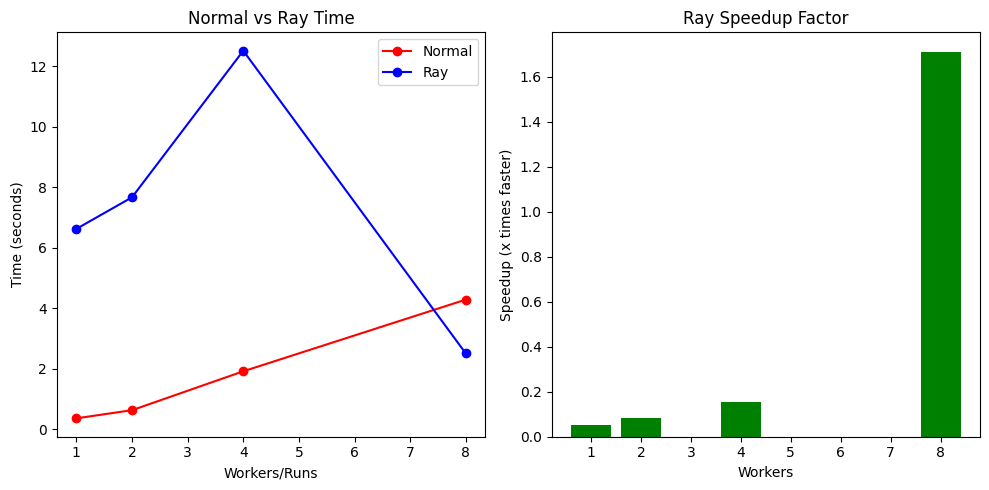


✅ Graph saved as speedup_graph.png


In [4]:
import warnings
warnings.filterwarnings("ignore")   # ❌ hide warnings

import time
import ray
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

ray.init(ignore_reinit_error=True, log_to_driver=False)

data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Normal training times (sequential)
def normal_train(runs):
    start = time.time()
    for _ in range(runs):
        model = RandomForestClassifier()
        model.fit(X_train, y_train)
    return time.time() - start

# Ray training times (parallel)
@ray.remote
def ray_train():
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

def ray_train_timed(workers):
    start = time.time()
    ray.get([ray_train.remote() for _ in range(workers)])
    return time.time() - start

worker_counts = [1, 2, 4, 8]
normal_times = [normal_train(w) for w in worker_counts]
ray_times    = [ray_train_timed(w) for w in worker_counts]
speedups     = [n/r for n, r in zip(normal_times, ray_times)]

print("\n📊 Speedup Analysis:")
print(f"{'Workers':<10} {'Normal(s)':<12} {'Ray(s)':<12} {'Speedup':<10}")
for i, w in enumerate(worker_counts):
    print(f"{w:<10} {normal_times[i]:<12.3f} {ray_times[i]:<12.3f} {speedups[i]:<10.2f}x")

# Graph
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(worker_counts, normal_times, 'ro-', label='Normal')
plt.plot(worker_counts, ray_times,   'bo-', label='Ray')
plt.xlabel('Workers/Runs')
plt.ylabel('Time (seconds)')
plt.title('Normal vs Ray Time')
plt.legend()

plt.subplot(1,2,2)
plt.bar(worker_counts, speedups, color='green')
plt.xlabel('Workers')
plt.ylabel('Speedup (x times faster)')
plt.title('Ray Speedup Factor')

plt.tight_layout()
plt.savefig('speedup_graph.png')
plt.show()
print("\n✅ Graph saved as speedup_graph.png")
ray.shutdown()

In [5]:
import warnings
warnings.filterwarnings("ignore")

import ray
import time
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

print("🔍 Hyperparameter Tuning (Normal vs Ray)")

# Initialize Ray
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, log_to_driver=False)

# Load dataset
data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Parameter grid
param_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_split': s}
    for n in [10, 50, 100]
    for d in [2, 5, None]
    for s in [2, 5]
]

# -------------------------------
# 🔹 Normal (Sequential Tuning)
# -------------------------------
def normal_tuning():
    start = time.time()

    best_score = 0
    best_params = None

    for params in param_grid:
        model = RandomForestClassifier(**params, random_state=42)
        score = cross_val_score(model, X_train, y_train, cv=3).mean()

        if score > best_score:
            best_score = score
            best_params = params

    end = time.time()

    return end - start, best_score, best_params


# -------------------------------
# ⚡ Ray (Parallel Tuning)
# -------------------------------
@ray.remote
def ray_evaluate(params):
    model = RandomForestClassifier(**params, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=3).mean()
    return score, params


def ray_tuning():
    start = time.time()

    futures = [ray_evaluate.remote(p) for p in param_grid]
    results = ray.get(futures)

    best_score, best_params = max(results, key=lambda x: x[0])

    end = time.time()

    return end - start, best_score, best_params


# -------------------------------
# 🚀 Run both methods
# -------------------------------
print("\n🔹 Running Normal Hyperparameter Tuning...")
n_time, n_score, n_params = normal_tuning()

print(f"✅ Normal Time: {n_time:.2f} sec")
print(f"✅ Normal Best Accuracy: {n_score:.4f}")
print(f"✅ Normal Best Params: {n_params}")

print("\n⚡ Running Ray Parallel Hyperparameter Tuning...")
r_time, r_score, r_params = ray_tuning()

print(f"✅ Ray Time: {r_time:.2f} sec")
print(f"✅ Ray Best Accuracy: {r_score:.4f}")
print(f"✅ Ray Best Params: {r_params}")

# -------------------------------
# 📊 Speedup
# -------------------------------
speedup = n_time / r_time

print(f"\n🚀 Speedup with Ray: {speedup:.2f}x")

# -------------------------------
# 💾 Save Results (IMPORTANT)
# -------------------------------
df = pd.DataFrame({
    "Method": ["Normal", "Ray"],
    "Time (seconds)": [n_time, r_time],
    "Best Accuracy": [n_score, r_score],
    "Best Params": [str(n_params), str(r_params)]
})

df.to_csv("tuning_results.csv", index=False)

print("\n✅ Results saved as tuning_results.csv")

# Shutdown Ray
ray.shutdown()

🔍 Hyperparameter Tuning (Normal vs Ray)


2026-04-25 21:06:43,764	INFO worker.py:2013 -- Started a local Ray instance.



🔹 Running Normal Hyperparameter Tuning...
✅ Normal Time: 20.78 sec
✅ Normal Best Accuracy: 0.9583
✅ Normal Best Params: {'n_estimators': 10, 'max_depth': 5, 'min_samples_split': 2}

⚡ Running Ray Parallel Hyperparameter Tuning...
✅ Ray Time: 27.66 sec
✅ Ray Best Accuracy: 0.9583
✅ Ray Best Params: {'n_estimators': 10, 'max_depth': 5, 'min_samples_split': 2}

🚀 Speedup with Ray: 0.75x

✅ Results saved as tuning_results.csv


        NORMAL vs RAY - REAL COMPARISON
 workers  normal_time  accuracy  ray_time  ray_accuracy  speedup
       1     0.937249       1.0  9.627261           1.0 0.097354
       2     1.643845       1.0  9.400475           1.0 0.174868
       4     2.830155       1.0 12.183679           1.0 0.232291
       8     5.447469       1.0  2.169360           1.0 2.511094


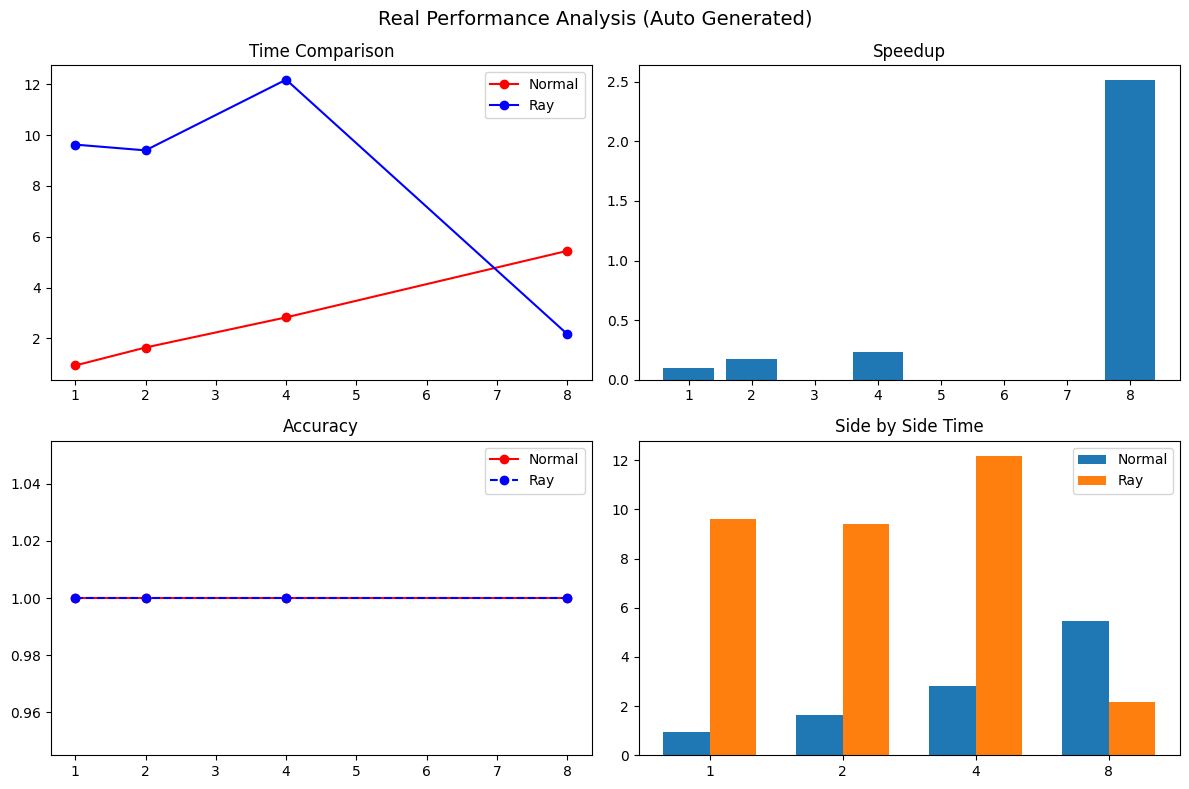


✅ Graph saved as final_graph.png


In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

# ✅ Load real data
normal_df = pd.read_csv("normal_results.csv")
ray_df = pd.read_csv("ray_results.csv")

# Merge data
df = pd.merge(normal_df, ray_df, on="workers")

# Speedup calculate
df["speedup"] = df["normal_time"] / df["ray_time"]

print("=" * 55)
print("        NORMAL vs RAY - REAL COMPARISON")
print("=" * 55)
print(df.to_string(index=False))
print("=" * 55)

workers = df["workers"]

# ✅ Graphs
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Real Performance Analysis (Auto Generated)", fontsize=14)

# 1️⃣ Time comparison
axes[0,0].plot(workers, df["normal_time"], 'ro-', label="Normal")
axes[0,0].plot(workers, df["ray_time"], 'bo-', label="Ray")
axes[0,0].set_title("Time Comparison")
axes[0,0].legend()

# 2️⃣ Speedup
axes[0,1].bar(workers, df["speedup"])
axes[0,1].set_title("Speedup")

# 3️⃣ Accuracy
axes[1,0].plot(workers, df["accuracy"], 'ro-', label="Normal")
axes[1,0].plot(workers, df["ray_accuracy"], 'bo--', label="Ray")
axes[1,0].set_title("Accuracy")
axes[1,0].legend()

# 4️⃣ Side-by-side
x = range(len(workers))
width = 0.35
axes[1,1].bar([i - width/2 for i in x], df["normal_time"], width, label="Normal")
axes[1,1].bar([i + width/2 for i in x], df["ray_time"], width, label="Ray")
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(workers)
axes[1,1].set_title("Side by Side Time")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("final_graph.png")
plt.show()

print("\n✅ Graph saved as final_graph.png")